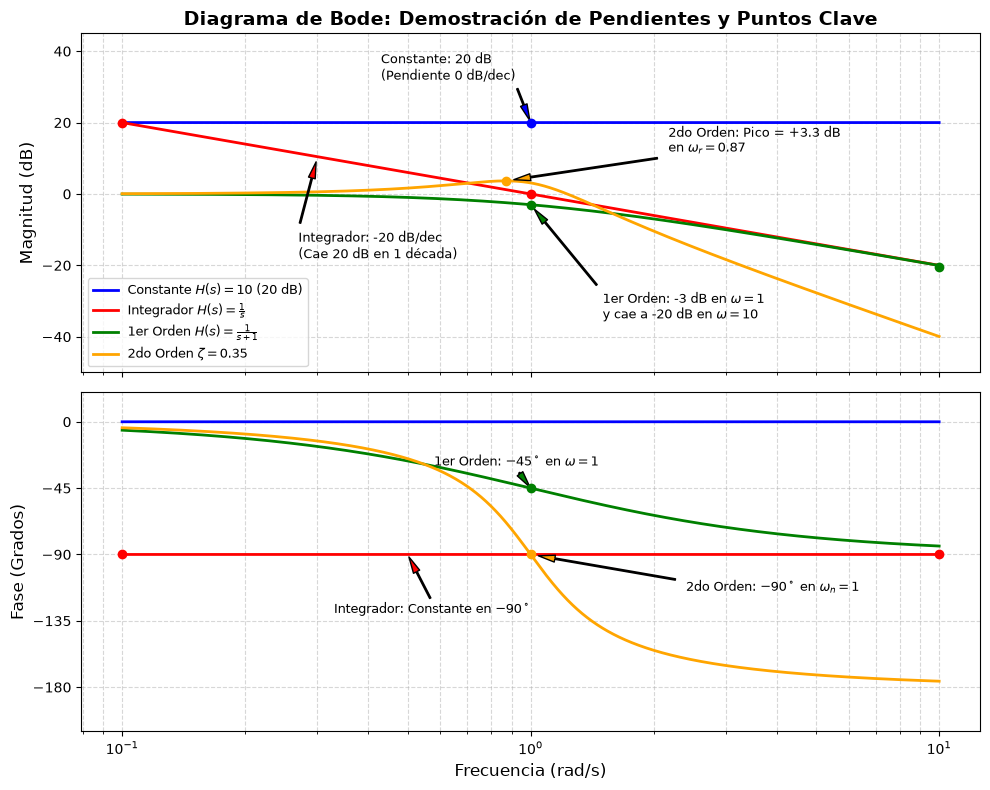

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Definir el vector de frecuencias
omega = np.logspace(-1, 1, 2000)
s = 1j * omega

# 1. Sistema Constante: H(s) = K (K = 10 -> 20 dB exactos)
K = 10
H_const = K * np.ones_like(omega, dtype=complex)

# 2. Sistema Integrador: H(s) = 1 / s
H_int = 1 / s

# 3. Sistema Lineal de 1er Orden: H(s) = 1 / (s + 1)
H_1st = 1 / (s + 1)

# 4. Sistema Lineal de 2do Orden: H(s) = 1 / (s^2 + 2*zeta*s + 1) con zeta = 0.35
zeta = 0.35
H_2nd = 1 / (s**2 + 2 * zeta * s + 1)


# Función para magnitud y fase
def get_bode(H):
  mag = 20 * np.log10(np.abs(H))
  phase = np.angle(H, deg=True)
  return mag, phase


mag_c, phase_c = get_bode(H_const)
mag_i, phase_i = get_bode(H_int)
mag_1, phase_1 = get_bode(H_1st)
mag_2, phase_2 = get_bode(H_2nd)

# Crear subplots
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- GRÁFICA DE MAGNITUD ---
ax_mag.semilogx(
    omega,
    mag_c,
    label='Constante $H(s) = 10$ (20 dB)',
    color='blue',
    linewidth=2,
)
ax_mag.semilogx(
    omega, mag_i, label='Integrador $H(s)=\\frac{1}{s}$', color='red', linewidth=2
)
ax_mag.semilogx(
    omega,
    mag_1,
    label='1er Orden $H(s)=\\frac{1}{s+1}$',
    color='green',
    linewidth=2,
)
ax_mag.semilogx(
    omega, mag_2, label=f'2do Orden $\\zeta={zeta}$', color='orange', linewidth=2
)

# 1. Anotación Constante en 20 dB
ax_mag.scatter([1], [20], color='blue', zorder=5)
ax_mag.annotate(
    'Constante: 20 dB\n(Pendiente 0 dB/dec)',
    xy=(1, 20),
    xytext=(0.43, 32),
    arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

# 2. Anotación Integrador (caída de 20 dB en 1 década, de omega=0.1 a omega=1)
ax_mag.scatter([0.1, 1], [20, 0], color='red', zorder=5)
ax_mag.annotate(
    'Integrador: -20 dB/dec\n(Cae 20 dB en 1 década)',
    xy=(0.3, 10),
    xytext=(0.27, -18),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

# 3. Anotación 1er Orden (Corte en -3 dB y caída posterior)
ax_mag.scatter([1, 10], [-3.01, -20.4], color='green', zorder=5)
ax_mag.annotate(
    '1er Orden: -3 dB en $\\omega=1$\ny cae a -20 dB en $\\omega=10$',
    xy=(1, -3.01),
    xytext=(1.5, -35),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

# 4. Anotación 2do Orden (Pico de resonancia)
omega_r = np.sqrt(1 - 2 * zeta**2)
mag_r = 20 * np.log10(1 / (2 * zeta * np.sqrt(1 - zeta**2)))
ax_mag.scatter([omega_r], [mag_r], color='orange', zorder=5)
ax_mag.annotate(
    f'2do Orden: Pico = +3.3 dB\nen $\\omega_r = {omega_r:.2f}$',
    xy=(omega_r, mag_r),
    xytext=(omega_r * 2.5, mag_r + 8),
    arrowprops=dict(facecolor='orange', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

ax_mag.set_title(
    'Diagrama de Bode: Demostración de Pendientes y Puntos Clave',
    fontsize=14,
    fontweight='bold',
)
ax_mag.set_ylabel('Magnitud (dB)', fontsize=12)
ax_mag.grid(True, which='both', ls='--', alpha=0.5)
ax_mag.legend(loc='lower left', fontsize=9)
ax_mag.set_ylim(-50, 45)

# --- GRÁFICA DE FASE ---
ax_phase.semilogx(omega, phase_c, label='Constante', color='blue', linewidth=2)
ax_phase.semilogx(omega, phase_i, label='Integrador', color='red', linewidth=2)
ax_phase.semilogx(omega, phase_1, label='1er Orden', color='green', linewidth=2)
ax_phase.semilogx(omega, phase_2, label='2do Orden', color='orange', linewidth=2)

# Puntos clave de fase
ax_phase.scatter([1], [-45], color='green', zorder=5)
ax_phase.annotate(
    '1er Orden: $-45^\\circ$ en $\\omega=1$',
    xy=(1, -45),
    xytext=(0.58, -30),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

ax_phase.scatter([1], [-90], color='orange', zorder=5)
ax_phase.annotate(
    '2do Orden: $-90^\\circ$ en $\\omega_n=1$',
    xy=(1, -90),
    xytext=(2.4, -115),
    arrowprops=dict(facecolor='orange', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

ax_phase.scatter([0.1, 10], [-90, -90], color='red', zorder=5)
ax_phase.annotate(
    'Integrador: Constante en $-90^\\circ$',
    xy=(0.5, -90),
    xytext=(0.33, -130),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
    fontsize=9,
)

ax_phase.set_xlabel('Frecuencia (rad/s)', fontsize=12)
ax_phase.set_ylabel('Fase (Grados)', fontsize=12)
ax_phase.grid(True, which='both', ls='--', alpha=0.5)
ax_phase.set_yticks([0, -45, -90, -135, -180, -270])
ax_phase.set_ylim(-210, 20)

plt.tight_layout()
plt.show()

In [6]:
pip install matplotlib numpy

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 28.1 MB/s  0:00:00m0:00:010:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 23.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
